In [1]:
import pandas as pd
import numpy as np

import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("dados/train_complete.csv")
df.drop(['exchange_exchange'], axis=1, inplace=True)
df.set_index('Date', inplace=True)

## Verificando Missing Values

In [3]:
round(((df.isna().sum().sort_values(ascending=False) / df.shape[0]) * 100), 2).value_counts()

0.0    118
Name: count, dtype: int64

In [4]:
df.isna().sum().value_counts()

0    118
Name: count, dtype: int64

---
# Seleção de variáveis
---

## Causalidade de Granger

#### Estacionarização das séries

In [5]:
extra_cols = [
    'epu_pt_epu', 'unemployment_up_15_unemployment', 
    'PPIPT_ppi', 'inflation_target'
]

In [6]:
def stationary(x, col_name):
    # Aplicar teste
    result = kpss(x, regression='ct')

    # outputs principais
    print("=" * 40)
    print(f"Coluna: {col_name.split('_')[0]}")
    print("=" * 40)
    print('KPSS Statistic:', result[0])
    print('p-value:', result[1])
    print('Estacionária: ', result[1] >= 0.05)
    if not result[1] >= 0.05:
        d = ndiffs(x, test='kpss')
        print('   Diferenciações necessárias: ', d)
    print('Critical Values:', result[3])

In [7]:
from statsmodels.tsa.stattools import kpss
from pmdarima.arima.utils import ndiffs

for col in extra_cols:
    stationary(df[col], col)
print("=" * 40)

Coluna: epu
KPSS Statistic: 0.10632577368114085
p-value: 0.1
Estacionária:  True
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
Coluna: unemployment
KPSS Statistic: 0.566222230106766
p-value: 0.01
Estacionária:  False
   Diferenciações necessárias:  2
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
Coluna: PPIPT
KPSS Statistic: 0.18314680755851132
p-value: 0.022319947165558254
Estacionária:  False
   Diferenciações necessárias:  0
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
Coluna: inflation
KPSS Statistic: 0.21933157424062677
p-value: 0.01
Estacionária:  False
   Diferenciações necessárias:  1
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2000138784.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(x, regression='ct')
C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2000138784.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(x, regression='ct')
C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2000138784.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(x, regression='ct')


Variáveis extras não estacionárias:
- `unemployment`: duas diferenciações
- `PPIPT`: ponderando aplicar um logaritmo somando `x` com `k`
    - `k=min(x)+0.1`
- `inflation`: uma diferenciação

In [8]:
extra_cols

['epu_pt_epu',
 'unemployment_up_15_unemployment',
 'PPIPT_ppi',
 'inflation_target']

In [9]:
abs(df['PPIPT_ppi'].min())

6.2

In [10]:
stationary(df['unemployment_up_15_unemployment'].diff(2).dropna(), 'unemployment_up_15_unemployment')
stationary(df['inflation_target'].diff().dropna(), 'inflation_target')
stationary(np.log(df['PPIPT_ppi'] + abs(df['PPIPT_ppi'].min()) + 0.1), 'PPIPT_ppi')
stationary(df['PPIPT_ppi'].diff().dropna(), 'PPIPT_ppi Diff')

Coluna: unemployment
KPSS Statistic: 0.14213625188215845
p-value: 0.05715508910711397
Estacionária:  True
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
Coluna: inflation
KPSS Statistic: 0.03548879679680336
p-value: 0.1
Estacionária:  True
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
Coluna: PPIPT
KPSS Statistic: 0.10258172126764203
p-value: 0.1
Estacionária:  True
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
Coluna: PPIPT
KPSS Statistic: 0.061870201956840815
p-value: 0.1
Estacionária:  True
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2000138784.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(x, regression='ct')
C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2000138784.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(x, regression='ct')
C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2000138784.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(x, regression='ct')


In [11]:
cols_fred_global = [
    'INDPRO', 'IPFINAL', 'IPCONGD',
    'AWOTMAN', 'AWHMAN', 'FEDFUNDS', 'GS1', 'GS5',
    'GS10', 'AAA', 'BAA', 'OILPRICEx', 'CUSR0000SAC',
    'PCEPI', 'S&P 500'
]

new_name = {col:f'{col}_fred-md' for col in cols_fred_global}

df_fred_md = pd.read_csv("dados/2026-01-MD.csv")[cols_fred_global].rename(new_name, axis=1)
df_fred_md.rename({'OILPRICEx_fred-md': 'OILPRICEx_fred-md_Eur'}, axis=1, inplace=True)
df_fred_md.iloc[0]

INDPRO_fred-md           5.0
IPFINAL_fred-md          5.0
IPCONGD_fred-md          5.0
AWOTMAN_fred-md          2.0
AWHMAN_fred-md           1.0
FEDFUNDS_fred-md         2.0
GS1_fred-md              2.0
GS5_fred-md              2.0
GS10_fred-md             2.0
AAA_fred-md              2.0
BAA_fred-md              2.0
OILPRICEx_fred-md_Eur    6.0
CUSR0000SAC_fred-md      6.0
PCEPI_fred-md            6.0
S&P 500_fred-md          5.0
Name: 0, dtype: float64

In [12]:
df_ea_md_qd = pd.read_excel("dados/EA-MD-QD-2026-02/raw/PTdata.xlsx", sheet_name='info')[['Name', 'TR1', 'Frequency']]

ea_transform = dict()
for idx in range(df_ea_md_qd.shape[0]):
    name, val, freq = df_ea_md_qd.iloc[idx]
    name = f'{name}_ea-md' if freq == 'M' else f'{name}_ea-qd'
    ea_transform[name] = val

pd.Series(ea_transform)[0:10]

GDP_PT_ea-qd       2
EXPGS_PT_ea-qd     2
IMPGS_PT_ea-qd     2
GFCE_PT_ea-qd      2
HFCE_PT_ea-qd      2
CONSD_PT_ea-qd     2
GCF_PT_ea-qd       2
GFCF_PT_ea-qd      2
GFACON_PT_ea-qd    2
GFAMG_PT_ea-qd     2
dtype: int64

In [13]:
def stacionarize_fred(X, code):
    if code == 1: return X
    elif code == 2: return X.diff()
    elif code == 3: return X.diff(2)
    elif code == 4: return np.log(X)
    elif code == 5: return np.log(X).diff()
    elif code == 6: return np.log(X).diff(2)
    return (X/X.shift() - 1).diff()


def stacionarize_ea(X, code):
    if code == 1: return 100 * stacionarize_fred(X, 4)
    elif code == 2: return 100 * stacionarize_fred(X, 5)
    elif code == 3: return 100 * stacionarize_fred(stacionarize_fred(X, 4), 3)
    elif code == 4: return X
    return stacionarize_fred(X, 2)


In [14]:
df_stacionary = df[['epu_pt_epu', 'PPIPT_ppi']].copy()

df_stacionary['unemployment_up_15_unemployment'] = stacionarize_fred(df['unemployment_up_15_unemployment'], 3)
df_stacionary['inflation_target'] = stacionarize_fred(df['inflation_target'], 2)
# df_stacionary['PPIPT_ppi'] = np.log(df['PPIPT_ppi'] + abs(df['PPIPT_ppi'].min()) + 0.1)

# Estacionarizando as variáveis da FRED-MD
for idx, val in df_fred_md.iloc[0].items():
    df_stacionary[idx] = stacionarize_fred(df[idx], val)
    
# Estacionarizando as variáveis da EA-MD-QD
for idx, val in pd.Series(ea_transform)[0:81].items():
    df_stacionary[idx] = stacionarize_ea(df[idx], val)

In [15]:
# Rode mais uma vez se não gostas de estar a ver estes warnings :)

for idx, val in pd.Series(ea_transform)[81:].items():
    df_stacionary[idx] = stacionarize_ea(df[idx], val)

df_stacionary.head()

C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2629099123.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_stacionary[idx] = stacionarize_ea(df[idx], val)
C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2629099123.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_stacionary[idx] = stacionarize_ea(df[idx], val)
C:\Users\josev\AppData\Local\Temp\ipykernel_59340\2629099123.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

,epu_pt_epu,PPIPT_ppi,unemployment_up_15_unemployment,inflation_target,INDPRO_fred-md,IPFINAL_fred-md,IPCONGD_fred-md,AWOTMAN_fred-md,AWHMAN_fred-md,FEDFUNDS_fred-md,...,DFGDP_PT_ea-qd,ICONFIX_PT_ea-md,CCONFIX_PT_ea-md,ESENTIX_PT_ea-md,KCONFIX_PT_ea-md,RTCONFIX_PT_ea-md,SCONFIX_PT_ea-md,BCI_PT_ea-md,CCI_PT_ea-md,SHIX_PT_ea-md
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,107.096201,21.5,NaN,NaN,NaN,NaN,NaN,NaN,41.5,NaN,...,NaN,7.3,-2.4,113.9,NaN,9.4,10.3,102.2262,102.3880,NaN
2000-02-01,105.539878,21.9,NaN,-0.3,0.003118,0.005419,0.006679,0.1,41.5,0.28,...,0.446157,8.9,-3.0,116.7,10.2,11.0,14.2,102.5146,102.2470,12.366348
2000-03-01,68.844150,21.2,-0.3,-0.3,0.003549,0.000055,-0.004811,-0.3,41.4,0.12,...,0.823810,7.7,-3.2,116.2,5.5,11.7,11.9,102.6476,101.9521,2.686605
2000-04-01,70.292778,20.0,-0.2,0.6,0.005935,0.007305,0.007288,0.1,41.6,0.17,...,-0.241874,8.8,-9.2,114.1,-13.4,6.1,13.2,102.7988,101.5175,-10.407950
2000-05-01,78.451666,17.9,0.0,0.4,0.002704,0.002443,0.000960,-0.1,41.2,0.25,...,0.362385,10.1,-8.0,113.3,9.8,1.5,6.0,102.8972,101.2843,-3.188878


In [16]:
from statsmodels.tsa.stattools import grangercausalitytests

# Perform Granger-Causality test
importancesCG = dict()
for causador in df_stacionary.drop('inflation_target', axis=1).columns:
    result = grangercausalitytests(df_stacionary[['inflation_target', causador]].dropna(), maxlag=[6])
    p_value = result[6][0]['ssr_ftest'][1]
    if p_value < 0.05:
        importancesCG[causador] = p_value


Granger Causality
number of lags (no zero) 6
ssr based F test:         F=0.4148  , p=0.8689  , df_denom=262, df_num=6
ssr based chi2 test:   chi2=2.6121  , p=0.8557  , df=6
likelihood ratio test: chi2=2.5998  , p=0.8571  , df=6
parameter F test:         F=0.4148  , p=0.8689  , df_denom=262, df_num=6

Granger Causality
number of lags (no zero) 6
ssr based F test:         F=5.3603  , p=0.0000  , df_denom=262, df_num=6
ssr based chi2 test:   chi2=33.7574 , p=0.0000  , df=6
likelihood ratio test: chi2=31.8408 , p=0.0000  , df=6
parameter F test:         F=5.3603  , p=0.0000  , df_denom=262, df_num=6

Granger Causality
number of lags (no zero) 6
ssr based F test:         F=1.3172  , p=0.2496  , df_denom=261, df_num=6
ssr based chi2 test:   chi2=8.2970  , p=0.2171  , df=6
likelihood ratio test: chi2=8.1739  , p=0.2256  , df=6
parameter F test:         F=1.3172  , p=0.2496  , df_denom=261, df_num=6

Granger Causality
number of lags (no zero) 6
ssr based F test:         F=1.5442  , p=0.1640  

In [17]:
importancesCG = pd.Series(importancesCG)
importancesCG

PPIPT_ppi                0.000031
GS1_fred-md              0.040471
GS5_fred-md              0.048912
OILPRICEx_fred-md_Eur    0.000481
CUSR0000SAC_fred-md      0.000389
PCEPI_fred-md            0.003620
EMPENT_PT_ea-qd          0.029732
REER42_PT_ea-md          0.038585
HICPOV_PT_ea-md          0.039423
HICPNEF_PT_ea-md         0.033282
HICPSV_PT_ea-md          0.005776
HICPNG_PT_ea-md          0.002021
DFGDP_PT_ea-qd           0.037331
CCONFIX_PT_ea-md         0.047588
dtype: float64

## Quais são as variáveis mais importantes?

In [18]:
model_selection = list()

for var in importancesCG.index:
    if var not in model_selection:
        model_selection.append(var)

model_selection

['PPIPT_ppi',
 'GS1_fred-md',
 'GS5_fred-md',
 'OILPRICEx_fred-md_Eur',
 'CUSR0000SAC_fred-md',
 'PCEPI_fred-md',
 'EMPENT_PT_ea-qd',
 'REER42_PT_ea-md',
 'HICPOV_PT_ea-md',
 'HICPNEF_PT_ea-md',
 'HICPSV_PT_ea-md',
 'HICPNG_PT_ea-md',
 'DFGDP_PT_ea-qd',
 'CCONFIX_PT_ea-md']

---
### As variáveis selecionadas foram

#### Seleção por modelos
- HICP excluindo energia (HICPNG-PT) 
- HICP total (HICPOV_PT)
- HICP excluindo energia e alimentos (HICPNEF-PT) 
- HICP excluindo Serviços (HICPSV-PT) 
- Treasury yelds 1 year (GS1) 
- Treasury yelds 5 years (GS5) 
- Preço do petróleo em Euros 
- _Índice de Preços do consumidor para todos os consumidores Urbanos: Commodities médios nas cidades de US_ 
    - Consumer Price Index for All Urban Consumers: Commodities in U.S. City Average (CUSR0000SAC) 
- Índice de Preços do Consumo Pessoal (PCEPI) 
- Empregos no setor de Entretenimento e outros serviços (EMPENT-PT) *
- Taxa de Câmbio real efetiva (REER42-PT) 
- Deflator do PIB (DFGDP-PT) *
- Custos na construção (CCONFIX-PT) 
- Taxa de variação homóloga do Índice de Preço de Produção (PPIPT)

#### Seleção pela teoria económica
- Índice de Incerteza Política (epu_pt_epu)
- Custo Unitário do Trabalho na Indústria (ULCIN_PT) *
- Exportações de bens e serviços (EXPGS_PT ) *
- Importações de bens e serviços (IMPGS_PT) *
- Indicador de confiança do Consumidor (CCI_PT)
- Produto Interno Bruto (GDP_PT) *
- Taxa de desemprego total (UNETOT_PT)

\* *Variáveis trimestrais*

---

In [25]:
teorical_variables = [
    'epu_pt_epu', 'GDP_PT_ea-qd', 'ULCIN_PT_ea-qd', 
    'EXPGS_PT_ea-qd', 'IMPGS_PT_ea-qd', 'CCI_PT_ea-md', 
    'UNETOT_PT_ea-md'
]

target = 'inflation_target'

df_train = df[model_selection + teorical_variables + [target, ]].copy()
df_train.head(4)

,PPIPT_ppi,GS1_fred-md,GS5_fred-md,OILPRICEx_fred-md_Eur,CUSR0000SAC_fred-md,PCEPI_fred-md,EMPENT_PT_ea-qd,REER42_PT_ea-md,HICPOV_PT_ea-md,HICPNEF_PT_ea-md,...,DFGDP_PT_ea-qd,CCONFIX_PT_ea-md,epu_pt_epu,GDP_PT_ea-qd,ULCIN_PT_ea-qd,EXPGS_PT_ea-qd,IMPGS_PT_ea-qd,CCI_PT_ea-md,UNETOT_PT_ea-md,inflation_target
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,21.5,6.12,6.58,27.760188,146.7,72.961,251.203770,96.14621,57.431740,62.712032,...,71.515980,-2.4,107.096201,43392.510865,63.215907,10321.943654,12861.845198,102.3880,5.6,2.1
2000-02-01,21.9,6.22,6.68,30.214124,147.6,73.191,251.246137,95.12462,57.437413,62.746704,...,71.835766,-3.0,105.539878,43410.337894,63.915202,10258.591955,13052.288749,102.2470,5.4,1.8
2000-03-01,21.2,6.22,6.50,31.288600,149.1,73.505,251.470000,94.49293,57.466046,62.816039,...,72.430000,-3.2,68.844150,43450.600000,64.800000,10151.500000,13257.600000,101.9521,5.3,1.5
2000-04-01,20.0,6.15,6.26,28.332416,148.5,73.444,251.937929,94.90064,57.722524,62.851899,...,72.255022,-9.2,70.292778,43354.566667,65.463501,10061.805642,13372.931249,101.5175,5.2,2.1


In [26]:
df_train.shape

(282, 22)

In [27]:
df_train.columns

Index(['PPIPT_ppi', 'GS1_fred-md', 'GS5_fred-md', 'OILPRICEx_fred-md_Eur',
       'CUSR0000SAC_fred-md', 'PCEPI_fred-md', 'EMPENT_PT_ea-qd',
       'REER42_PT_ea-md', 'HICPOV_PT_ea-md', 'HICPNEF_PT_ea-md',
       'HICPSV_PT_ea-md', 'HICPNG_PT_ea-md', 'DFGDP_PT_ea-qd',
       'CCONFIX_PT_ea-md', 'epu_pt_epu', 'GDP_PT_ea-qd', 'ULCIN_PT_ea-qd',
       'EXPGS_PT_ea-qd', 'IMPGS_PT_ea-qd', 'CCI_PT_ea-md', 'UNETOT_PT_ea-md',
       'inflation_target'],
      dtype='object')

# Estacionarizando as variáveis

In [28]:
df_train['PPIPT_ppi'].min()

-6.2

In [29]:
df_final_stacionary = df_train[['epu_pt_epu']].copy()

df_final_stacionary['inflation_target'] = stacionarize_fred(df_train['inflation_target'], 2)
df_final_stacionary['PPIPT_ppi'] = np.log(df_train['PPIPT_ppi'] + abs(df_train['PPIPT_ppi'].min()) + 0.1)

fred_var = [var for var in df_train.columns if '_fred-md' in var]
ea_var = [var for var in df_train.columns if '_ea-' in var]

# Estacionarizando as variáveis da FRED-MD
for idx, val in df_fred_md[fred_var].iloc[0].items():
    df_final_stacionary[idx] = stacionarize_fred(df_train[idx], val)

# Estacionarizando as variáveis da EA-MD-QD
for idx, val in pd.Series(ea_transform)[ea_var].items():
    df_final_stacionary[idx] = stacionarize_ea(df_train[idx], val)

df_final_stacionary.head()

,epu_pt_epu,inflation_target,PPIPT_ppi,GS1_fred-md,GS5_fred-md,OILPRICEx_fred-md_Eur,CUSR0000SAC_fred-md,PCEPI_fred-md,EMPENT_PT_ea-qd,REER42_PT_ea-md,...,HICPSV_PT_ea-md,HICPNG_PT_ea-md,DFGDP_PT_ea-qd,CCONFIX_PT_ea-md,GDP_PT_ea-qd,ULCIN_PT_ea-qd,EXPGS_PT_ea-qd,IMPGS_PT_ea-qd,CCI_PT_ea-md,UNETOT_PT_ea-md
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,107.096201,NaN,3.325036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-2.4,NaN,NaN,NaN,NaN,102.3880,NaN
2000-02-01,105.539878,-0.3,3.339322,0.10,0.10,NaN,NaN,NaN,0.016864,-1.02159,...,0.177079,0.279953,0.446157,-3.0,0.041075,1.100126,-0.615649,1.469831,102.2470,-0.2
2000-03-01,68.844150,-0.3,3.314186,0.00,-0.18,0.119651,0.016228,0.007428,0.089061,-0.63169,...,0.131228,0.014668,0.823810,-3.2,0.092705,1.374837,-1.049412,1.560747,101.9521,-0.1
2000-04-01,70.292778,0.6,3.269569,-0.07,-0.24,-0.064303,0.006079,0.003451,0.185905,0.40771,...,0.127484,3.720325,-0.241874,-9.2,-0.221262,1.018715,-0.887484,0.866163,101.5175,-0.1
2000-05-01,78.451666,0.4,3.186353,0.18,0.43,-0.011325,-0.004032,0.000000,0.250760,0.06696,...,0.315931,-0.425857,0.362385,-8.0,-0.221753,0.366824,-0.333989,-0.071786,101.2843,0.1


In [30]:
df_final_stacionary.to_csv("dados/train_stationary.csv")

# Tratamento de Outliers

In [31]:
def outliers(X, level=0):
    """
        - X: variável onde se verifica os outliers
        - level: default 0 - outliers não severos; 1 outliers severos
    """

    assert level in (0, 1), "Level invalido - valores aceites (0, 1)"

    out_level = (1.5, 3)
    Q1 = X.quantile(.25)
    Q3 = X.quantile(.75)
    IQR = Q3 - Q1

    left = Q1 - out_level[level] * IQR
    right = Q3 + out_level[level] * IQR

    return (left, right)

In [32]:
variables = dict()

for col in df_train.columns:
    left, right = outliers(df_train[col])
    variables[col] = df_train.loc[(df_train[col] < left) | (df_train[col] > right)].shape[0]

pd.Series(variables).sort_values(ascending=False)

PPIPT_ppi                25
ULCIN_PT_ea-qd           14
GDP_PT_ea-qd             14
CUSR0000SAC_fred-md      12
inflation_target         11
epu_pt_epu               10
DFGDP_PT_ea-qd            1
OILPRICEx_fred-md_Eur     1
PCEPI_fred-md             0
UNETOT_PT_ea-md           0
CCI_PT_ea-md              0
IMPGS_PT_ea-qd            0
EXPGS_PT_ea-qd            0
GS5_fred-md               0
CCONFIX_PT_ea-md          0
EMPENT_PT_ea-qd           0
GS1_fred-md               0
HICPSV_PT_ea-md           0
HICPNEF_PT_ea-md          0
HICPOV_PT_ea-md           0
REER42_PT_ea-md           0
HICPNG_PT_ea-md           0
dtype: int64

In [33]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

out_variables = pd.Series(variables).sort_values(ascending=False)

cols_quantile = [col for col in out_variables[out_variables > 0].index if col != 'inflation_target']
cols_standard = out_variables[out_variables == 0].index.tolist()

# Define os transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), cols_standard),
        ('quantile', QuantileTransformer(n_quantiles=min(100, df_train.shape[0]), 
                                         output_distribution='normal',
                                         random_state=322
                                        ), cols_quantile)
    ],
    remainder='passthrough'  # mantém outras colunas sem alteração
)

transformer = preprocessor.fit(df_train)

In [34]:
cols_out = cols_standard + cols_quantile + [col for col in df_train.columns if col not in cols_standard + cols_quantile]

df_transformed = pd.DataFrame(transformer.transform(df_train), columns=cols_out)
df_transformed.index = df_train.index
df_transformed.head()

,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,REER42_PT_ea-md,HICPNG_PT_ea-md,PPIPT_ppi,ULCIN_PT_ea-qd,GDP_PT_ea-qd,CUSR0000SAC_fred-md,epu_pt_epu,DFGDP_PT_ea-qd,OILPRICEx_fred-md_Eur,inflation_target
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-1.672367,-1.181375,1.622256,-1.292128,-1.333842,2.651460,1.612561,-1.857139,2.370485,-2.090914,...,-2.037451,-1.810267,2.112112,-2.309865,-1.911430,-5.199338,0.579501,-5.199338,-1.466960,2.1
2000-02-01,-1.652773,-1.239516,1.555927,-1.236524,-1.348731,2.718651,1.557800,-1.854185,2.425870,-2.082324,...,-2.347105,-1.802991,2.266949,-2.113992,-1.853788,-2.531313,0.517177,-2.683129,-1.118196,1.8
2000-03-01,-1.626023,-1.268586,1.417198,-1.176579,-1.373899,2.597707,1.539546,-1.838577,2.425870,-2.075948,...,-2.538577,-1.802610,1.956981,-1.917631,-1.759427,-1.888129,-1.118873,-2.309995,-0.958600,1.5
2000-04-01,-1.631220,-1.297657,1.212752,-1.142906,-1.394979,2.436448,0.991927,-1.805954,2.387100,-2.069746,...,-2.414996,-1.703956,1.819146,-1.779384,-2.062445,-2.049594,-1.083752,-2.389831,-1.336194,2.1
2000-05-01,-1.626023,-1.268586,1.103049,-1.145707,-1.402864,2.725370,1.101451,-1.761853,2.486794,-2.054342,...,-2.394699,-1.715435,1.700008,-1.741123,-2.276094,-2.049594,-0.669207,-2.273296,-0.992480,2.5


In [35]:
import joblib

# guardar no disco
joblib.dump(transformer, "models/preprocessor.pkl")

['models/preprocessor.pkl']

In [36]:
cols_out

['PCEPI_fred-md',
 'UNETOT_PT_ea-md',
 'CCI_PT_ea-md',
 'IMPGS_PT_ea-qd',
 'EXPGS_PT_ea-qd',
 'GS5_fred-md',
 'CCONFIX_PT_ea-md',
 'EMPENT_PT_ea-qd',
 'GS1_fred-md',
 'HICPSV_PT_ea-md',
 'HICPNEF_PT_ea-md',
 'HICPOV_PT_ea-md',
 'REER42_PT_ea-md',
 'HICPNG_PT_ea-md',
 'PPIPT_ppi',
 'ULCIN_PT_ea-qd',
 'GDP_PT_ea-qd',
 'CUSR0000SAC_fred-md',
 'epu_pt_epu',
 'DFGDP_PT_ea-qd',
 'OILPRICEx_fred-md_Eur',
 'inflation_target']

# Defasamento das Features

In [37]:
target = 'inflation_target'
df_lags = df_transformed.copy()
lags = dict()

for col in df_transformed.drop(target, axis=1).columns:
    lags[col] = list()
    lags[col].append(df_lags[[col, target]].corr()[col].values[-1])
    for lag in range(1, 13):
        new_var = f'{col}_lag{lag}'
        df_lags[new_var] = df_lags[col].shift(lag)
        lags[col].append(df_lags[[new_var, target]].corr()[new_var].values[-1])

df_lags = df_lags.copy()

C:\Users\josev\AppData\Local\Temp\ipykernel_59340\3876981247.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lags[new_var] = df_lags[col].shift(lag)
C:\Users\josev\AppData\Local\Temp\ipykernel_59340\3876981247.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lags[new_var] = df_lags[col].shift(lag)
C:\Users\josev\AppData\Local\Temp\ipykernel_59340\3876981247.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

In [38]:
lag_df = pd.DataFrame(lags)
cols = dict()
for col in lag_df.columns:
    clean = col.replace('_fred-md', '').replace('_ea-md', '').replace('_ea-qd', '').replace('_Eur', '')
    cols[col] = clean

lag_df.rename(cols, axis=1, inplace=True)
lag_df.T

,0,1,2,3,4,5,6,7,8,9,10,11,12
PCEPI,-0.017848,-0.023084,-0.030400,-0.039327,-0.046835,-0.053873,-0.060472,-0.066603,-0.072572,-0.079264,-0.085894,-0.091891,-0.097061
UNETOT_PT,-0.363086,-0.376440,-0.389733,-0.402273,-0.411539,-0.418317,-0.422674,-0.425663,-0.428816,-0.431281,-0.432609,-0.432797,-0.432822
CCI_PT,-0.245555,-0.221759,-0.190299,-0.151150,-0.109372,-0.067975,-0.027998,0.010289,0.046670,0.081841,0.115069,0.145089,0.171038
IMPGS_PT,0.090341,0.092889,0.093894,0.093179,0.091490,0.087328,0.080603,0.072369,0.063461,0.053845,0.044105,0.034212,0.024460
EXPGS_PT,-0.002459,-0.009236,-0.017905,-0.027992,-0.038034,-0.049491,-0.062930,-0.078168,-0.094916,-0.113023,-0.130999,-0.147848,-0.162668
GS5,0.466527,0.460549,0.450043,0.439690,0.427278,0.411886,0.392600,0.370098,0.348013,0.326860,0.303958,0.280097,0.256150
CCONFIX_PT,-0.241735,-0.217350,-0.189132,-0.149166,-0.104769,-0.065863,-0.027850,0.010908,0.045906,0.079497,0.112896,0.140324,0.167855
EMPENT_PT,-0.108946,-0.131069,-0.156017,-0.183661,-0.209639,-0.233074,-0.253210,-0.270336,-0.285808,-0.300605,-0.313502,-0.323284,-0.329430
GS1,0.492596,0.477276,0.458366,0.438312,0.415011,0.389056,0.360342,0.331125,0.303003,0.275658,0.249233,0.224090,0.200130
HICPSV_PT,-0.144145,-0.155105,-0.166236,-0.178763,-0.188304,-0.196337,-0.203048,-0.207967,-0.212213,-0.216523,-0.220194,-0.221861,-0.222770


In [39]:
import matplotlib.pyplot as plt

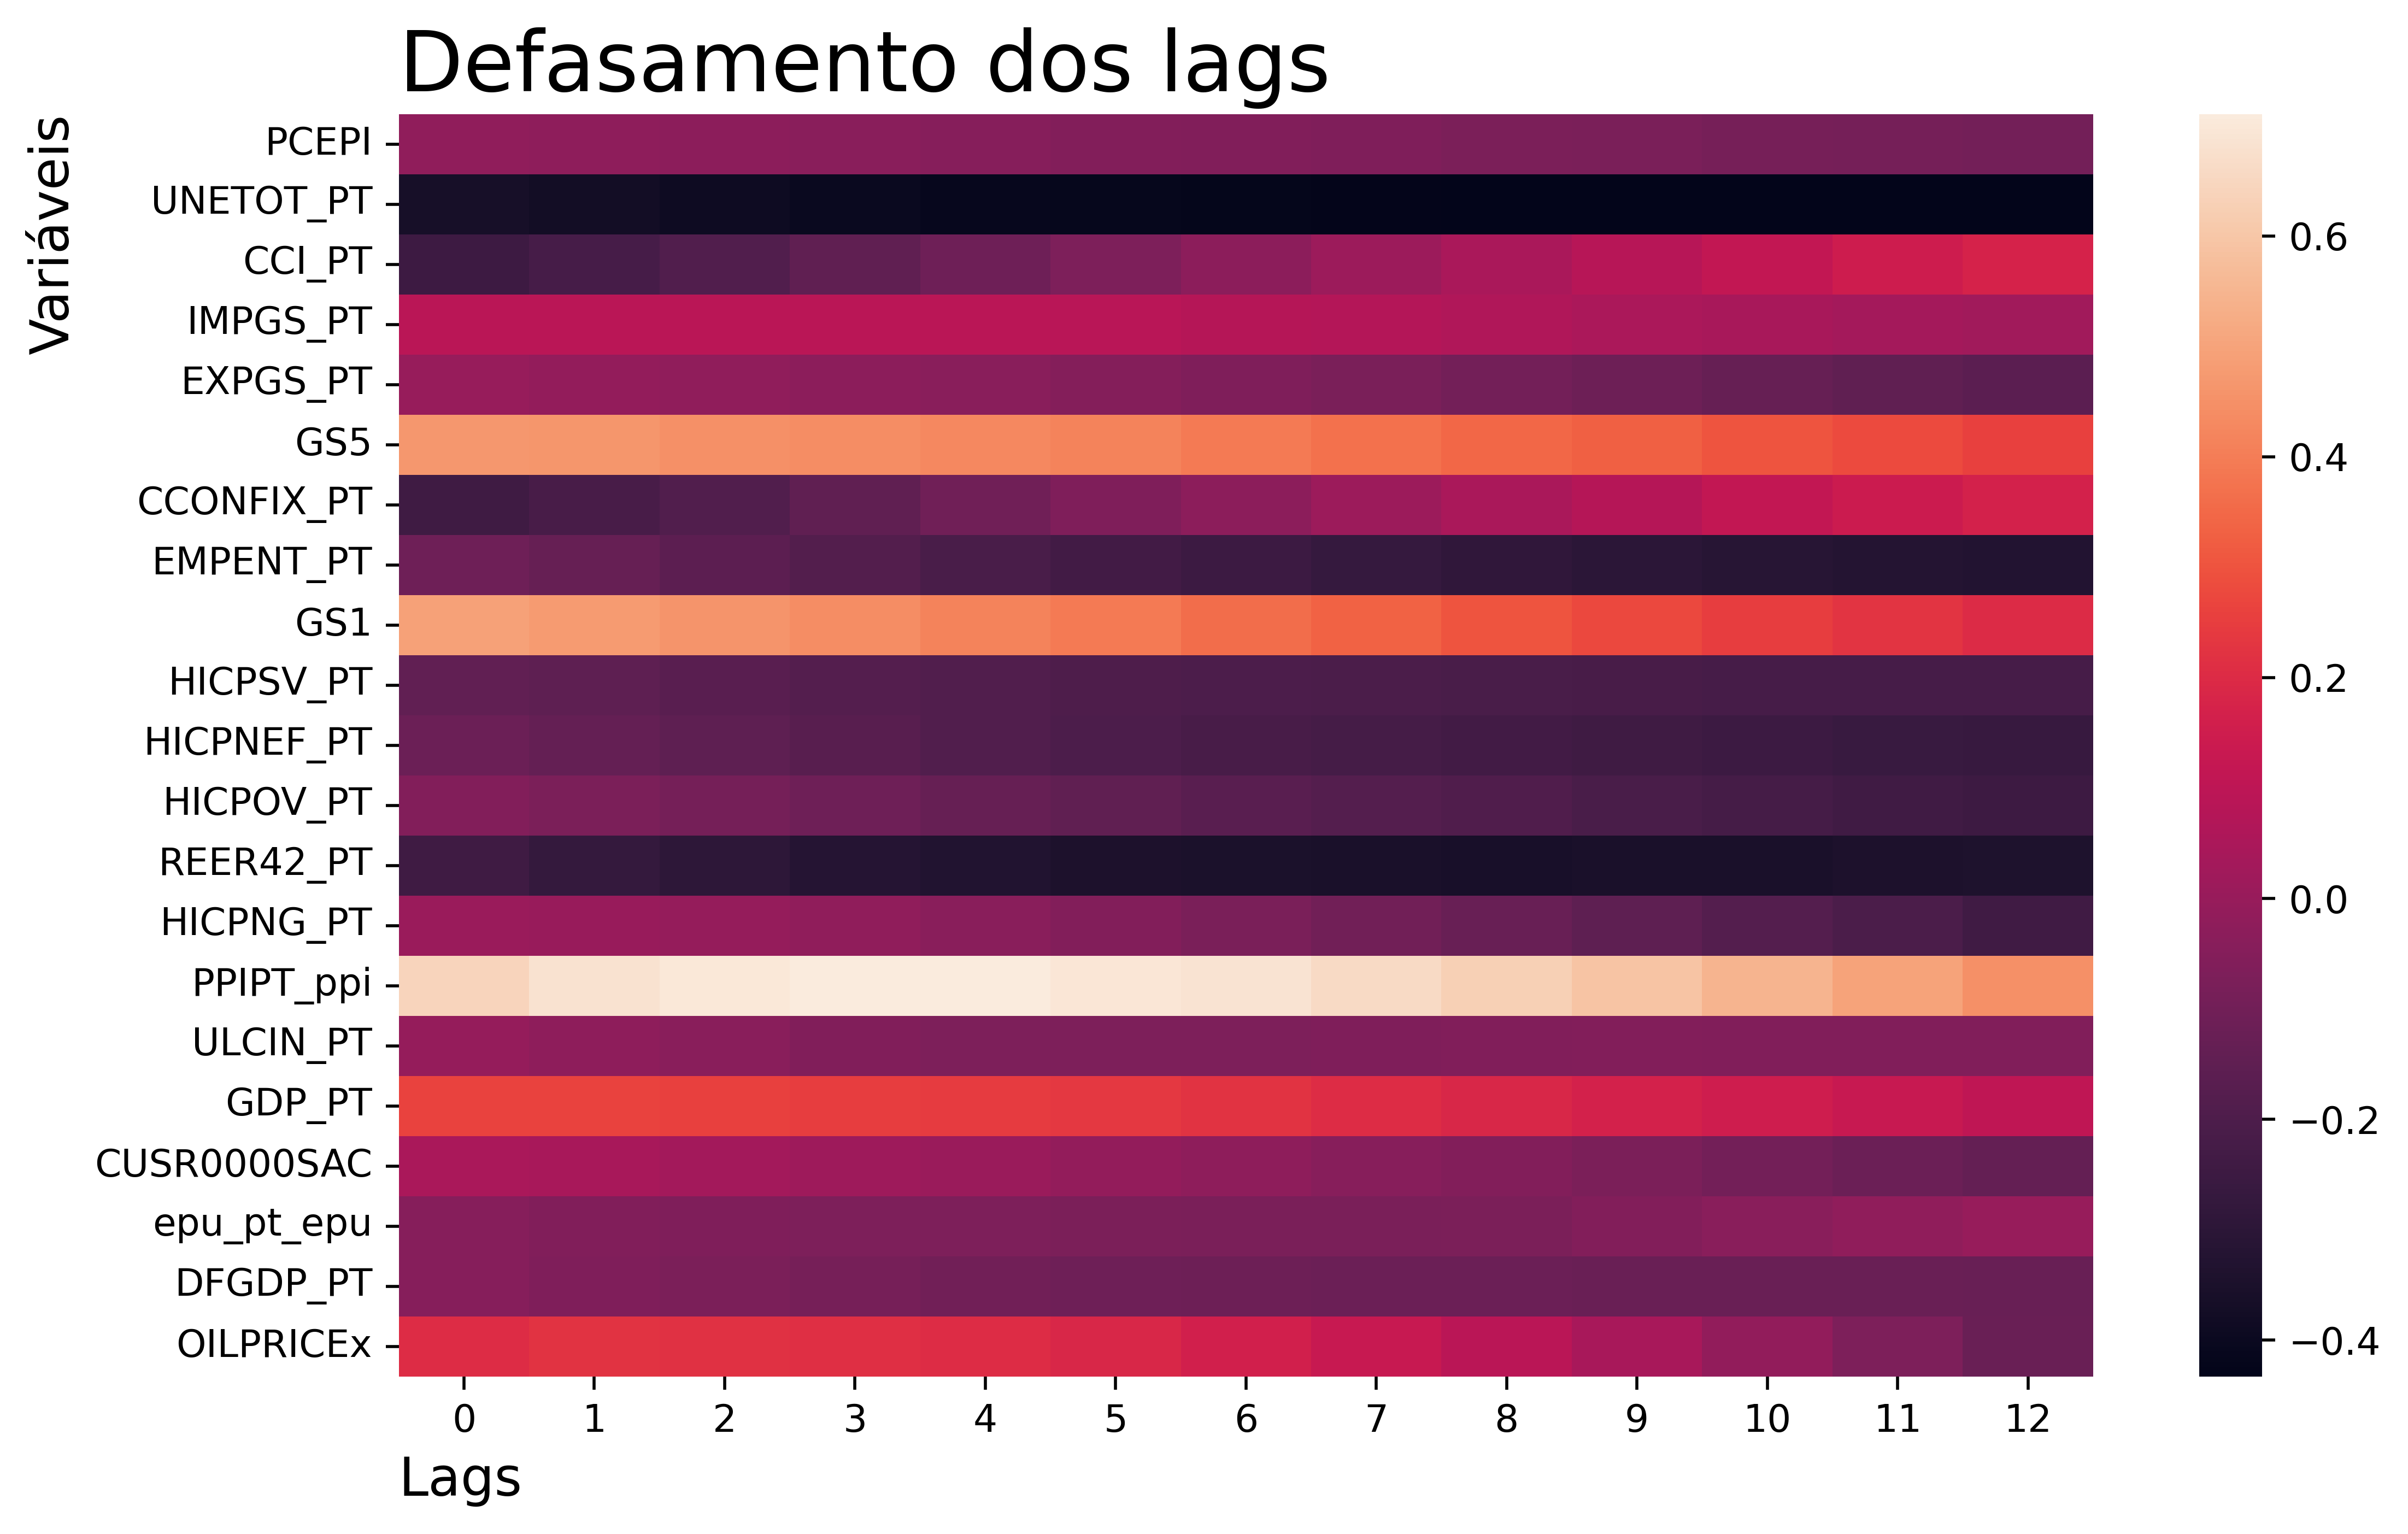

In [41]:
plt.figure(figsize=(10, 6), dpi=500)

sns.heatmap(lag_df.T, annot=False)

plt.xlabel("Lags", loc='left', fontdict={
    'fontsize':14
})
plt.ylabel("Variáveis", loc='top', fontdict={
    'fontsize':14
})
plt.title("Defasamento dos lags", loc='left', fontdict={
    'fontsize':22
})

plt.show()

In [42]:
df_lags.head()

,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,OILPRICEx_fred-md_Eur_lag3,OILPRICEx_fred-md_Eur_lag4,OILPRICEx_fred-md_Eur_lag5,OILPRICEx_fred-md_Eur_lag6,OILPRICEx_fred-md_Eur_lag7,OILPRICEx_fred-md_Eur_lag8,OILPRICEx_fred-md_Eur_lag9,OILPRICEx_fred-md_Eur_lag10,OILPRICEx_fred-md_Eur_lag11,OILPRICEx_fred-md_Eur_lag12
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-1.672367,-1.181375,1.622256,-1.292128,-1.333842,2.651460,1.612561,-1.857139,2.370485,-2.090914,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-02-01,-1.652773,-1.239516,1.555927,-1.236524,-1.348731,2.718651,1.557800,-1.854185,2.425870,-2.082324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-01,-1.626023,-1.268586,1.417198,-1.176579,-1.373899,2.597707,1.539546,-1.838577,2.425870,-2.075948,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-01,-1.631220,-1.297657,1.212752,-1.142906,-1.394979,2.436448,0.991927,-1.805954,2.387100,-2.069746,...,-1.466960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-01,-1.626023,-1.268586,1.103049,-1.145707,-1.402864,2.725370,1.101451,-1.761853,2.486794,-2.054342,...,-1.118196,-1.46696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# df_lags.to_csv("Test zone/dados.csv", index=False)

In [44]:
df_lags.shape

(282, 274)

In [45]:
from sklearn.linear_model import Lasso

In [46]:
lags_selected = dict()

for col in df_train.drop('inflation_target', axis=1).columns:
    clf = Lasso(alpha=0.1, max_iter=1000, random_state=322)
    
    cols_lag = [lag_col for lag_col in df_lags.columns if col == lag_col[:len(col)]]
    data = df_lags[cols_lag + [target,]].copy()
    data.dropna(inplace=True)
    X = data.drop(target, axis=1)
    y = data[target]

    clf.fit(X, y)

    coef_selected = list()
    coef = np.abs(clf.coef_)
    for i, lag_selected in enumerate(X.columns):
        if coef[i] != 0:
            coef_selected.append(lag_selected)

    lags_selected[col] = coef_selected
    
lags_selected

{'PPIPT_ppi': ['PPIPT_ppi',
  'PPIPT_ppi_lag1',
  'PPIPT_ppi_lag2',
  'PPIPT_ppi_lag3',
  'PPIPT_ppi_lag4',
  'PPIPT_ppi_lag6',
  'PPIPT_ppi_lag7',
  'PPIPT_ppi_lag8',
  'PPIPT_ppi_lag9',
  'PPIPT_ppi_lag10',
  'PPIPT_ppi_lag11',
  'PPIPT_ppi_lag12'],
 'GS1_fred-md': ['GS1_fred-md', 'GS1_fred-md_lag10'],
 'GS5_fred-md': ['GS5_fred-md', 'GS5_fred-md_lag12'],
 'OILPRICEx_fred-md_Eur': ['OILPRICEx_fred-md_Eur',
  'OILPRICEx_fred-md_Eur_lag1',
  'OILPRICEx_fred-md_Eur_lag2',
  'OILPRICEx_fred-md_Eur_lag3',
  'OILPRICEx_fred-md_Eur_lag4',
  'OILPRICEx_fred-md_Eur_lag5',
  'OILPRICEx_fred-md_Eur_lag6',
  'OILPRICEx_fred-md_Eur_lag7',
  'OILPRICEx_fred-md_Eur_lag12'],
 'CUSR0000SAC_fred-md': ['CUSR0000SAC_fred-md',
  'CUSR0000SAC_fred-md_lag1',
  'CUSR0000SAC_fred-md_lag2',
  'CUSR0000SAC_fred-md_lag11',
  'CUSR0000SAC_fred-md_lag12'],
 'PCEPI_fred-md': ['PCEPI_fred-md', 'PCEPI_fred-md_lag12'],
 'EMPENT_PT_ea-qd': ['EMPENT_PT_ea-qd', 'EMPENT_PT_ea-qd_lag12'],
 'REER42_PT_ea-md': ['REER42_PT_e

In [47]:
for col, lags in lags_selected.items():
    print("=" * 40)
    print(f"Coluna: {col}")
    print("=" * 40)
    for lag in lags:
        print(f"- {lag}")

Coluna: PPIPT_ppi
- PPIPT_ppi
- PPIPT_ppi_lag1
- PPIPT_ppi_lag2
- PPIPT_ppi_lag3
- PPIPT_ppi_lag4
- PPIPT_ppi_lag6
- PPIPT_ppi_lag7
- PPIPT_ppi_lag8
- PPIPT_ppi_lag9
- PPIPT_ppi_lag10
- PPIPT_ppi_lag11
- PPIPT_ppi_lag12
Coluna: GS1_fred-md
- GS1_fred-md
- GS1_fred-md_lag10
Coluna: GS5_fred-md
- GS5_fred-md
- GS5_fred-md_lag12
Coluna: OILPRICEx_fred-md_Eur
- OILPRICEx_fred-md_Eur
- OILPRICEx_fred-md_Eur_lag1
- OILPRICEx_fred-md_Eur_lag2
- OILPRICEx_fred-md_Eur_lag3
- OILPRICEx_fred-md_Eur_lag4
- OILPRICEx_fred-md_Eur_lag5
- OILPRICEx_fred-md_Eur_lag6
- OILPRICEx_fred-md_Eur_lag7
- OILPRICEx_fred-md_Eur_lag12
Coluna: CUSR0000SAC_fred-md
- CUSR0000SAC_fred-md
- CUSR0000SAC_fred-md_lag1
- CUSR0000SAC_fred-md_lag2
- CUSR0000SAC_fred-md_lag11
- CUSR0000SAC_fred-md_lag12
Coluna: PCEPI_fred-md
- PCEPI_fred-md
- PCEPI_fred-md_lag12
Coluna: EMPENT_PT_ea-qd
- EMPENT_PT_ea-qd
- EMPENT_PT_ea-qd_lag12
Coluna: REER42_PT_ea-md
- REER42_PT_ea-md_lag6
- REER42_PT_ea-md_lag7
- REER42_PT_ea-md_lag8
- REER

In [48]:
tot = 0
for lags in lags_selected.values():
    tot += len(lags)

tot

74

In [49]:
lags_for_var = dict()
for var, lags in lags_selected.items():
    lags_for_var[var] = list()
    for lag in lags:
        if 'lag' in lag:
            lags_for_var[var].append(int(lag.split('lag')[-1]))

lags_for_var

{'PPIPT_ppi': [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12],
 'GS1_fred-md': [10],
 'GS5_fred-md': [12],
 'OILPRICEx_fred-md_Eur': [1, 2, 3, 4, 5, 6, 7, 12],
 'CUSR0000SAC_fred-md': [1, 2, 11, 12],
 'PCEPI_fred-md': [12],
 'EMPENT_PT_ea-qd': [12],
 'REER42_PT_ea-md': [6, 7, 8, 9, 10, 11, 12],
 'HICPOV_PT_ea-md': [12],
 'HICPNEF_PT_ea-md': [12],
 'HICPSV_PT_ea-md': [12],
 'HICPNG_PT_ea-md': [1, 3, 4, 12],
 'DFGDP_PT_ea-qd': [12],
 'CCONFIX_PT_ea-md': [1, 2, 11, 12],
 'epu_pt_epu': [6, 7, 8],
 'GDP_PT_ea-qd': [1, 2, 3, 4, 5, 12],
 'ULCIN_PT_ea-qd': [12],
 'EXPGS_PT_ea-qd': [12],
 'IMPGS_PT_ea-qd': [2, 3],
 'CCI_PT_ea-md': [12],
 'UNETOT_PT_ea-md': [12]}

In [50]:
tot = 0
for lags in lags_for_var.values():
    tot += len(lags)

tot

61

# Defasamentos da variável alvo

In [51]:
from statsmodels.tsa.stattools import acf

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

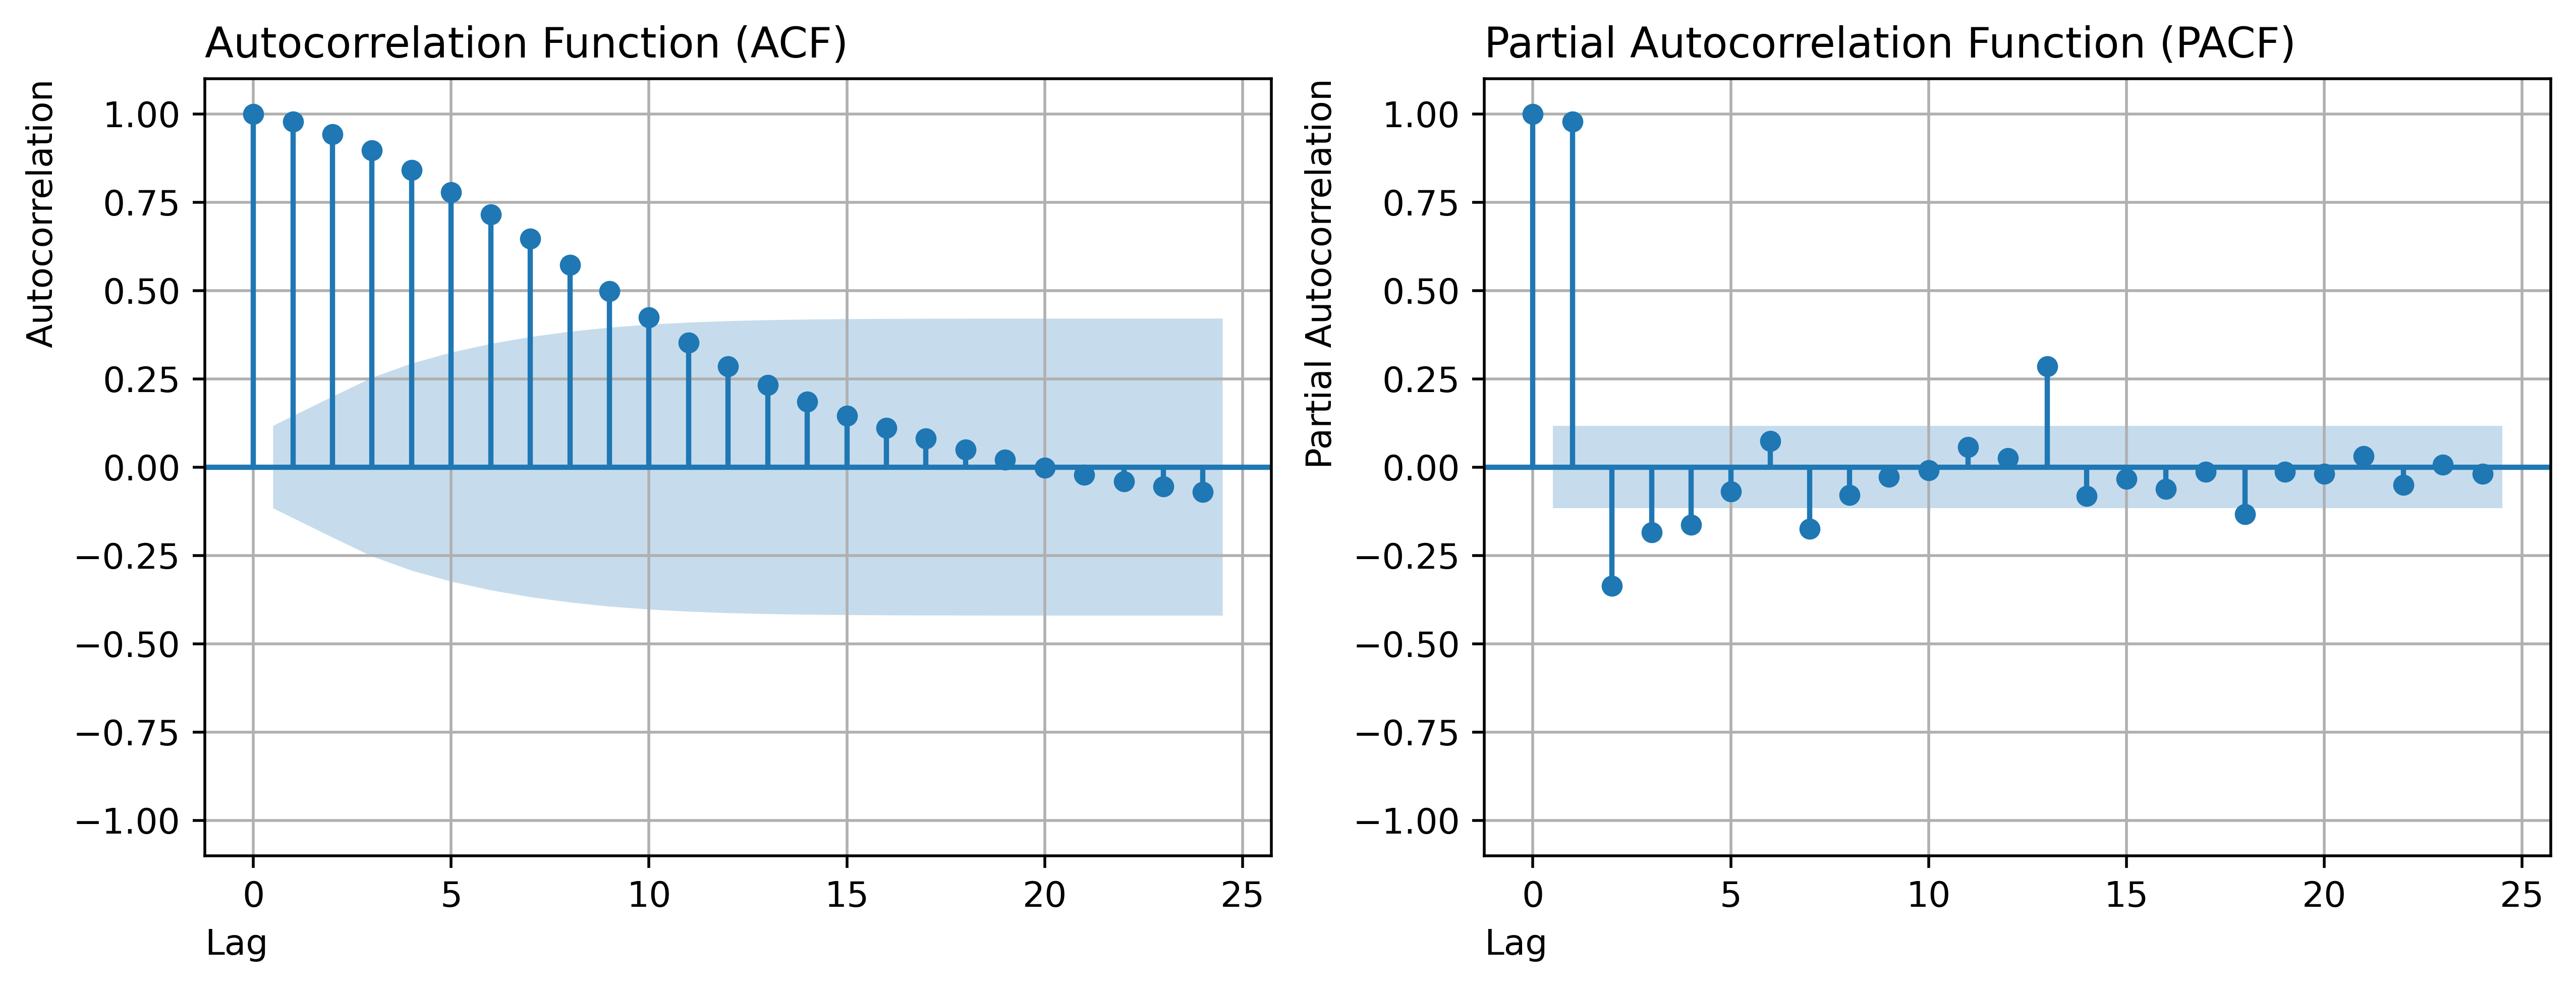

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=500)

plot_acf(
    df_train['inflation_target'], 
    lags=24, alpha=.05, title='',
    ax=ax[0])

plot_pacf(
    df_train['inflation_target'], 
    lags=24, alpha=.05, title='',
    ax=ax[1])

ax[0].set_title("Autocorrelation Function (ACF)", loc='Left')
ax[0].set_xlabel("Lag", loc='left')
ax[0].set_ylabel("Autocorrelation", loc='top')
ax[0].set_ylim(-1.10, 1.10)

ax[1].set_title("Partial Autocorrelation Function (PACF)", loc='Left')
ax[1].set_xlabel("Lag", loc='left')
ax[1].set_ylabel("Partial Autocorrelation", loc='top')
ax[1].set_ylim(-1.10, 1.10)

ax[0].grid(True)
ax[1].grid(True)

plt.show()

A inflação em Portugal é afetada por uma memória de curto prazo, ou seja, a inflação homóloga do ano anterior não demontra ter relação estatiscamente significativa com a inflação do ano atual, no entanto, a inflação dos últimos 6-8 meses demonstra sempre ter grande impacto na inflação do presente.

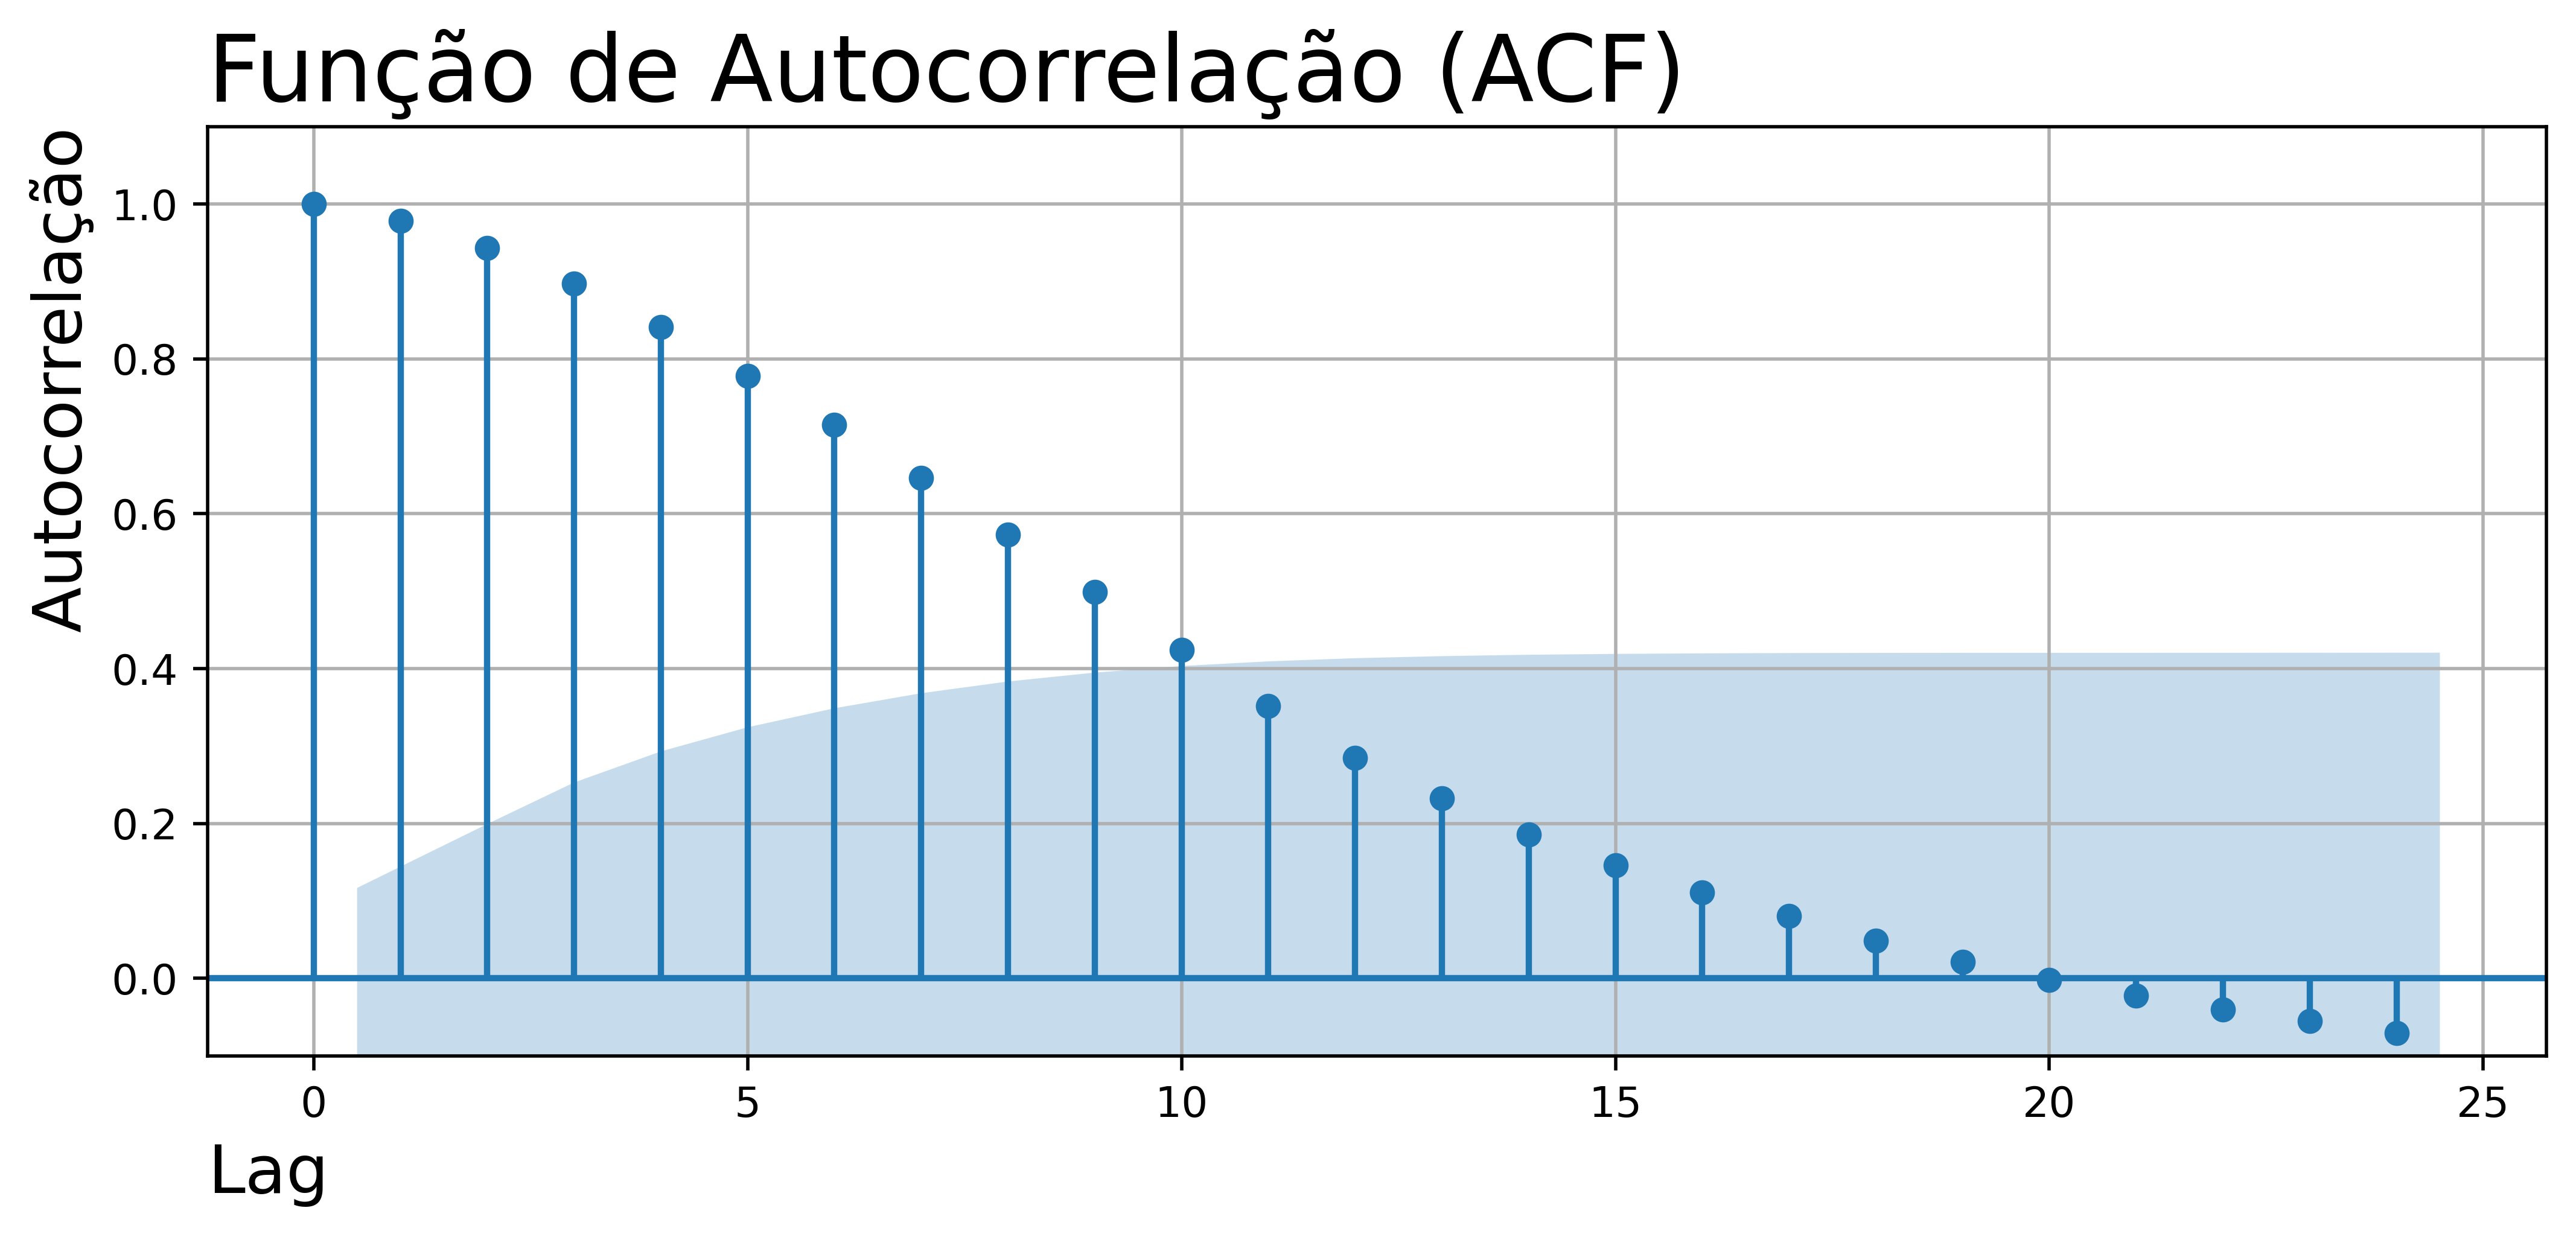

In [54]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=500)

plot_acf(
    df_train['inflation_target'], 
    lags=24, alpha=.05, title='',
    ax=ax)

ax.set_title("Função de Autocorrelação (ACF)", loc='Left', 
            fontdict=dict(fontsize=22))
ax.set_xlabel("Lag", loc='left',
             fontdict=dict(fontsize=16))
ax.set_ylabel("Autocorrelação", loc='top',
             fontdict=dict(fontsize=16))

ax.set_ylim(-0.10, 1.10)
ax.grid(True)
plt.show()

In [55]:
df_transformed.head(3)

,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,REER42_PT_ea-md,HICPNG_PT_ea-md,PPIPT_ppi,ULCIN_PT_ea-qd,GDP_PT_ea-qd,CUSR0000SAC_fred-md,epu_pt_epu,DFGDP_PT_ea-qd,OILPRICEx_fred-md_Eur,inflation_target
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-1.672367,-1.181375,1.622256,-1.292128,-1.333842,2.651460,1.612561,-1.857139,2.370485,-2.090914,...,-2.037451,-1.810267,2.112112,-2.309865,-1.911430,-5.199338,0.579501,-5.199338,-1.466960,2.1
2000-02-01,-1.652773,-1.239516,1.555927,-1.236524,-1.348731,2.718651,1.557800,-1.854185,2.425870,-2.082324,...,-2.347105,-1.802991,2.266949,-2.113992,-1.853788,-2.531313,0.517177,-2.683129,-1.118196,1.8
2000-03-01,-1.626023,-1.268586,1.417198,-1.176579,-1.373899,2.597707,1.539546,-1.838577,2.425870,-2.075948,...,-2.538577,-1.802610,1.956981,-1.917631,-1.759427,-1.888129,-1.118873,-2.309995,-0.958600,1.5


In [56]:
target = 'inflation_target'
df_lags_target = df_transformed[[target]].copy()

for lag in range(1, 13):
    new_var = f'{target}_lag{lag}'
    df_lags_target[new_var] = df_lags_target[target].shift(lag)

# df_lags_target.dropna(inplace=True)
X = df_lags_target.dropna().drop(target, axis=1)
y = df_lags_target[target].iloc[12:]

clf = Lasso(alpha=0.1, max_iter=1000, random_state=322)

clf.fit(X, y)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,322
,selection,'cyclic'


In [57]:
coef = np.abs(clf.coef_)
var_coef = dict()

for i, col in enumerate(X.columns):
    # print(f"{col} - {coef[i]}")
    if coef[i] != 0:
        var_coef[col] = coef[i]

pd.Series(var_coef).sort_values(ascending=False)

inflation_target_lag1     0.977512
inflation_target_lag11    0.043256
inflation_target_lag10    0.007089
dtype: float64

In [58]:
df_lags.head()

,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,OILPRICEx_fred-md_Eur_lag3,OILPRICEx_fred-md_Eur_lag4,OILPRICEx_fred-md_Eur_lag5,OILPRICEx_fred-md_Eur_lag6,OILPRICEx_fred-md_Eur_lag7,OILPRICEx_fred-md_Eur_lag8,OILPRICEx_fred-md_Eur_lag9,OILPRICEx_fred-md_Eur_lag10,OILPRICEx_fred-md_Eur_lag11,OILPRICEx_fred-md_Eur_lag12
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-1.672367,-1.181375,1.622256,-1.292128,-1.333842,2.651460,1.612561,-1.857139,2.370485,-2.090914,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-02-01,-1.652773,-1.239516,1.555927,-1.236524,-1.348731,2.718651,1.557800,-1.854185,2.425870,-2.082324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-01,-1.626023,-1.268586,1.417198,-1.176579,-1.373899,2.597707,1.539546,-1.838577,2.425870,-2.075948,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-01,-1.631220,-1.297657,1.212752,-1.142906,-1.394979,2.436448,0.991927,-1.805954,2.387100,-2.069746,...,-1.466960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-01,-1.626023,-1.268586,1.103049,-1.145707,-1.402864,2.725370,1.101451,-1.761853,2.486794,-2.054342,...,-1.118196,-1.46696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
df_final = df_lags[[col for col in df_lags.columns if 'lag' not in col]].copy()
df_final.head()

,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,REER42_PT_ea-md,HICPNG_PT_ea-md,PPIPT_ppi,ULCIN_PT_ea-qd,GDP_PT_ea-qd,CUSR0000SAC_fred-md,epu_pt_epu,DFGDP_PT_ea-qd,OILPRICEx_fred-md_Eur,inflation_target
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-1.672367,-1.181375,1.622256,-1.292128,-1.333842,2.651460,1.612561,-1.857139,2.370485,-2.090914,...,-2.037451,-1.810267,2.112112,-2.309865,-1.911430,-5.199338,0.579501,-5.199338,-1.466960,2.1
2000-02-01,-1.652773,-1.239516,1.555927,-1.236524,-1.348731,2.718651,1.557800,-1.854185,2.425870,-2.082324,...,-2.347105,-1.802991,2.266949,-2.113992,-1.853788,-2.531313,0.517177,-2.683129,-1.118196,1.8
2000-03-01,-1.626023,-1.268586,1.417198,-1.176579,-1.373899,2.597707,1.539546,-1.838577,2.425870,-2.075948,...,-2.538577,-1.802610,1.956981,-1.917631,-1.759427,-1.888129,-1.118873,-2.309995,-0.958600,1.5
2000-04-01,-1.631220,-1.297657,1.212752,-1.142906,-1.394979,2.436448,0.991927,-1.805954,2.387100,-2.069746,...,-2.414996,-1.703956,1.819146,-1.779384,-2.062445,-2.049594,-1.083752,-2.389831,-1.336194,2.1
2000-05-01,-1.626023,-1.268586,1.103049,-1.145707,-1.402864,2.725370,1.101451,-1.761853,2.486794,-2.054342,...,-2.394699,-1.715435,1.700008,-1.741123,-2.276094,-2.049594,-0.669207,-2.273296,-0.992480,2.5


In [60]:
for col, lags in lags_selected.items():
    for lag in lags:
        if 'lag' in lag:
            df_final[lag] = df_lags[lag]

df_final.head()

,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,GDP_PT_ea-qd_lag3,GDP_PT_ea-qd_lag4,GDP_PT_ea-qd_lag5,GDP_PT_ea-qd_lag12,ULCIN_PT_ea-qd_lag12,EXPGS_PT_ea-qd_lag12,IMPGS_PT_ea-qd_lag2,IMPGS_PT_ea-qd_lag3,CCI_PT_ea-md_lag12,UNETOT_PT_ea-md_lag12
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-1.672367,-1.181375,1.622256,-1.292128,-1.333842,2.651460,1.612561,-1.857139,2.370485,-2.090914,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-02-01,-1.652773,-1.239516,1.555927,-1.236524,-1.348731,2.718651,1.557800,-1.854185,2.425870,-2.082324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-01,-1.626023,-1.268586,1.417198,-1.176579,-1.373899,2.597707,1.539546,-1.838577,2.425870,-2.075948,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.292128,NaN,NaN,NaN
2000-04-01,-1.631220,-1.297657,1.212752,-1.142906,-1.394979,2.436448,0.991927,-1.805954,2.387100,-2.069746,...,-1.911430,NaN,NaN,NaN,NaN,NaN,-1.236524,-1.292128,NaN,NaN
2000-05-01,-1.626023,-1.268586,1.103049,-1.145707,-1.402864,2.725370,1.101451,-1.761853,2.486794,-2.054342,...,-1.853788,-1.91143,NaN,NaN,NaN,NaN,-1.176579,-1.236524,NaN,NaN


In [61]:
df_lags_target.head()

,inflation_target,inflation_target_lag1,inflation_target_lag2,inflation_target_lag3,inflation_target_lag4,inflation_target_lag5,inflation_target_lag6,inflation_target_lag7,inflation_target_lag8,inflation_target_lag9,inflation_target_lag10,inflation_target_lag11,inflation_target_lag12
Date,,,,,,,,,,,,,
2000-01-01,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-02-01,1.8,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-01,1.5,1.8,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-01,2.1,1.5,1.8,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-01,2.5,2.1,1.5,1.8,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
df_final['inflation_target_lag1'] = df_lags_target['inflation_target_lag1']
df_final.to_csv('dados/train_lags.csv', index=True)